In [2]:
%pip install numpy
%pip install torchvision
%pip install matplotlib
%pip install torch

In [3]:
import numpy as np
from torchvision import datasets, transforms

train_data = datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.5MB/s]

100%|██████████| 29.5k/29.5k [00:00<00:00, 271kB/s]

100%|██████████| 4.42M/4.42M [00:00<00:00, 5.08MB/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 20.0MB/s]



In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
import random

# Set device to CUDA (GPU) if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Generating modular visualization...


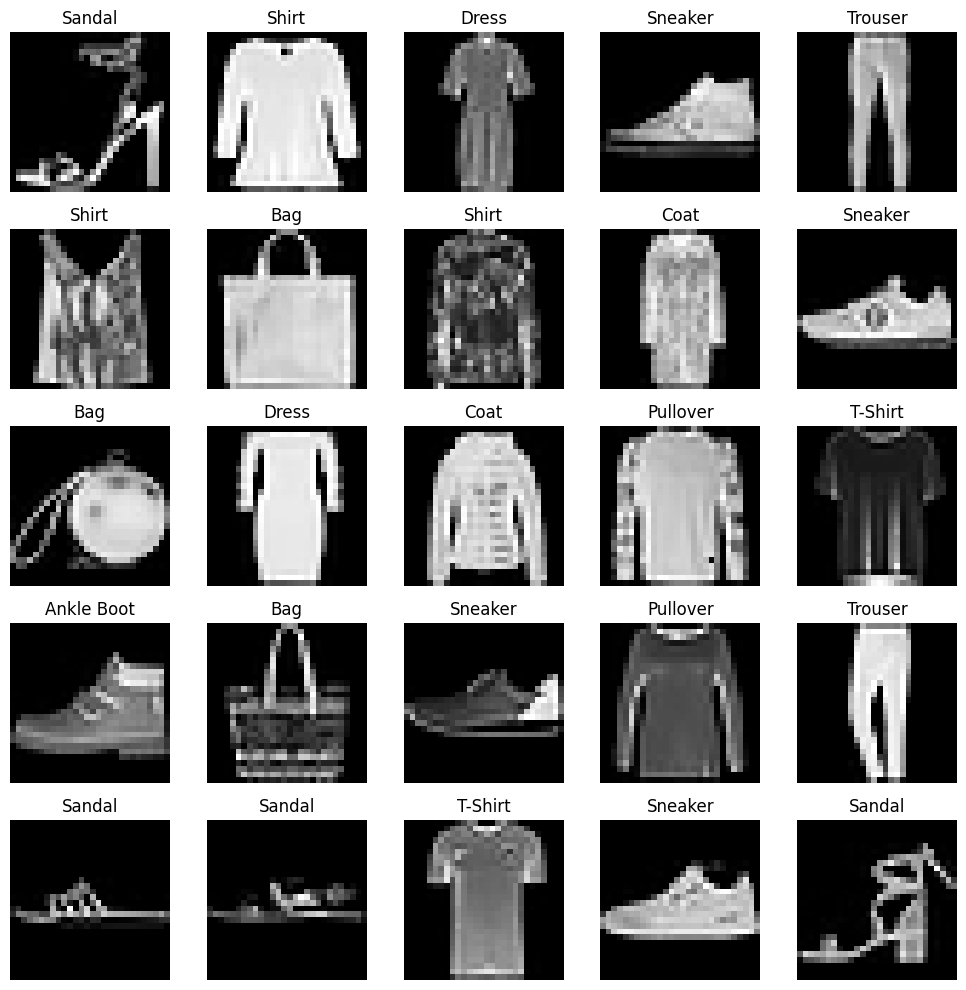

In [7]:
import torch
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the Dataset
# We use 'train=True' to inspect the training data
'''train_set = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)'''

# 2. Define the Label Map
# Fashion MNIST has 10 classes, mapped as follows:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

# 3. Visualization Function
# 1. Function to show a single image on a specific axis
def show_single_image(img, label_text, ax):
    """
    Renders a single tensor image onto a matplotlib axis.
    """
    # Squeeze removes the channel dimension (1, 28, 28) -> (28, 28)
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(label_text)
    ax.axis("off")

# 2. Function to create the grid layout
def create_plot_grid(image_label_pairs, rows=5, cols=5):
    """
    Takes a list of (image, label_text) tuples and plots them in a grid.
    """
    figure = plt.figure(figsize=(10, 10))
    
    # Ensure we don't try to plot more items than we have space for
    count = min(len(image_label_pairs), rows * cols)
    
    for i in range(count):
        img, label_text = image_label_pairs[i]
        
        # Add subplot (index starts at 1)
        ax = figure.add_subplot(rows, cols, i + 1)
        
        # Call our single image helper
        show_single_image(img, label_text, ax)
    
    plt.tight_layout()
    plt.show()
    return figure

# 3. Function to handle the dataset logic
def visualize_dataset_samples(dataset, rows=5, cols=5):
    """
    Extracts random samples from the dataset and triggers the visualization.
    """
    samples = []
    total_items = rows * cols
    
    for _ in range(total_items):
        # Pick a random index
        sample_idx = torch.randint(len(dataset), size=(1,)).item()
        img, label_idx = dataset[sample_idx]
        
        # Convert numeric label to text (using the global labels_map)
        label_text = labels_map[label_idx]
        
        samples.append((img, label_text))
    
    # Pass the data to the plotter
    create_plot_grid(samples, rows, cols)

# --- Usage ---
print("Generating modular visualization...")
visualize_dataset_samples(train_data)


In [ ]:
import random
from torch.utils.data import Dataset

class SiameseNetworkDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.transform = self.dataset.transform
        
        # Group indices by label for faster access
        # e.g. {0: [1, 5, 12...], 1: [2, 9, ...]}
        self.label_to_indices = {i: [] for i in range(10)}
        for idx in range(len(self.dataset)):
            label = self.dataset.targets[idx].item()
            self.label_to_indices[label].append(idx)

    def __getitem__(self, index):
        # 1. Get the first image (Anchor)
        img1, label1 = self.dataset[index]

        # 2. Determine if we want a positive (same class) or negative (diff class) pair
        # We aim for roughly 50/50 distribution
        should_get_same_class = random.randint(0, 1) 
        
        if should_get_same_class:
            # Positive Pair: Pick another random index from the SAME label bucket
            idx2 = random.choice(self.label_to_indices[label1])
        else:
            # Negative Pair: Pick a random label that is NOT label1
            diff_label = random.randint(0, 9)
            while diff_label == label1:
                diff_label = random.randint(0, 9)
            # Pick an index from that different label bucket
            idx2 = random.choice(self.label_to_indices[diff_label])

        img2, label2 = self.dataset[idx2]
        
        # 3. Create the Target Label
        # Convention for Contrastive Loss: 0 = Similar, 1 = Dissimilar
        target = torch.tensor([0], dtype=torch.float32) if label1 == label2 else torch.tensor([1], dtype=torch.float32)

        return img1, img2, target

    def __len__(self):
        return len(self.dataset)



tensor([0.])


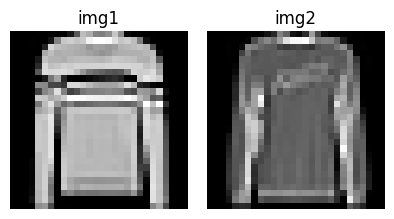

In [9]:
def test_siamese_picker():
    picker = SiameseNetworkDataset(train_data)
    img1,img2,target = picker.__getitem__(5)
    l = []
    l.append([img1,"img1"])
    l.append([img2,"img2"])
    print(target) # if 0 positive else negative
    create_plot_grid(l)
test_siamese_picker()


In [29]:
class StableSiamese(nn.Module):
    def __init__(self):
        super(StableSiamese, self).__init__()
        
        # BatchNorm is the key fix here. It prevents the "stuck" loss.
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5),
            nn.BatchNorm2d(32), # <--- Forces non-zero features
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=5),
            nn.BatchNorm2d(64), # <--- Forces non-zero features
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 32) # Output 32 Features (Rich enough to avoid collapse)
        )

    def forward_one(self, x):
        output = self.cnn(x)
        output = output.view(output.size()[0], -1)
        output = self.fc(output)
        return output

    def forward(self, input1, input2):
        output1 = self.forward_one(input1)
        output2 = self.forward_one(input2)
        return output1, output2


In [ ]:
def visualize_result(model, dataset):
    # Use Original Train Set for labels
    loader = DataLoader(dataset, batch_size=1000, shuffle=True)
    images, labels = next(iter(loader))
    images = images.to(device)
    
    model.eval()
    with torch.no_grad():
        embeddings = model.forward_one(images)
        embeddings = embeddings.cpu().numpy()
        labels = labels.cpu().numpy()
    
    # PCA to 2D
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    
    plt.figure(figsize=(10, 10))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap='tab10', alpha=0.6)
    plt.legend(handles=scatter.legend_elements()[0], labels=[labels_map[i] for i in np.unique(labels)])
    plt.title("Fashion MNIST Embeddings (Cosine Loss + BatchNorm)")
    plt.show()

# Run visualization immediately


In [ ]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Euclidean distance
        euclidean_distance = F.pairwise_distance(output1, output2)
        
        # Calculate loss
        # Label 0: Similar (pull together) -> minimize distance
        # Label 1: Dissimilar (push apart) -> maximize distance up to margin
        loss_contrastive = torch.mean((1-label) * torch.pow(euclidean_distance, 2) +
                                      (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss_contrastive

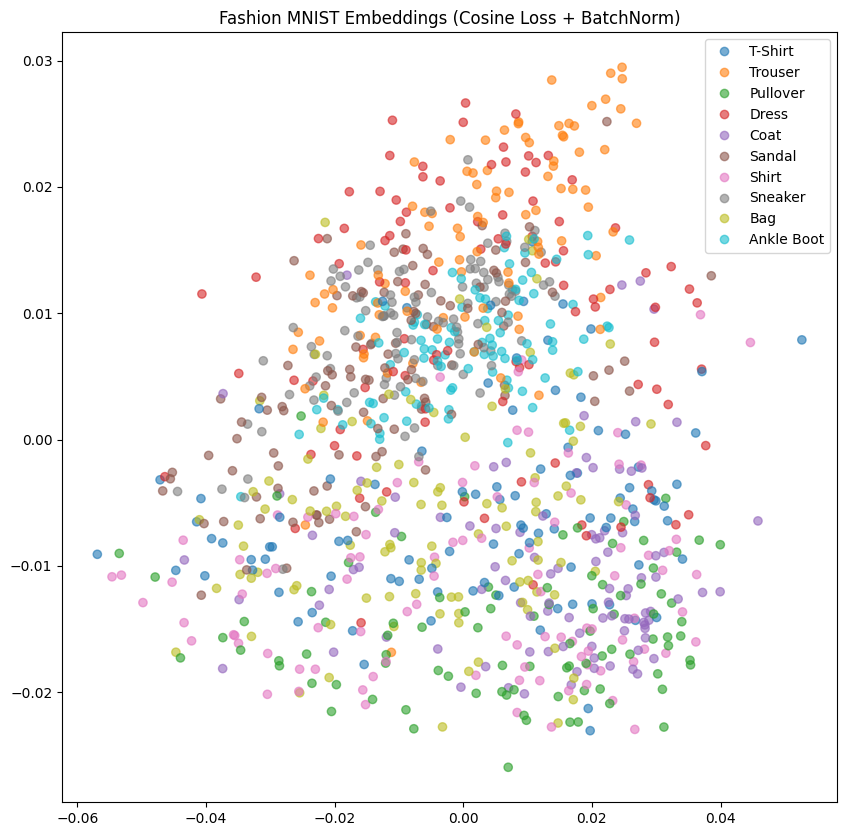

Starting Stabilized Training...
Epoch 1 | Total: 0.0710 | Same Loss: 0.0581 | Diff Loss: 0.0841
Epoch 1 | Total: 0.0710 | Same Loss: 0.0581 | Diff Loss: 0.0841
Epoch 2 | Total: 0.0540 | Same Loss: 0.0511 | Diff Loss: 0.0570
Epoch 2 | Total: 0.0540 | Same Loss: 0.0511 | Diff Loss: 0.0570
Epoch 3 | Total: 0.0494 | Same Loss: 0.0453 | Diff Loss: 0.0534
Epoch 3 | Total: 0.0494 | Same Loss: 0.0453 | Diff Loss: 0.0534
Epoch 4 | Total: 0.0452 | Same Loss: 0.0411 | Diff Loss: 0.0493
Epoch 4 | Total: 0.0452 | Same Loss: 0.0411 | Diff Loss: 0.0493
Epoch 5 | Total: 0.0451 | Same Loss: 0.0398 | Diff Loss: 0.0503
Epoch 5 | Total: 0.0451 | Same Loss: 0.0398 | Diff Loss: 0.0503
Epoch 6 | Total: 0.0426 | Same Loss: 0.0378 | Diff Loss: 0.0473
Epoch 6 | Total: 0.0426 | Same Loss: 0.0378 | Diff Loss: 0.0473
Epoch 7 | Total: 0.0413 | Same Loss: 0.0368 | Diff Loss: 0.0458
Epoch 7 | Total: 0.0413 | Same Loss: 0.0368 | Diff Loss: 0.0458
Epoch 8 | Total: 0.0408 | Same Loss: 0.0363 | Diff Loss: 0.0454
Epoch 8 

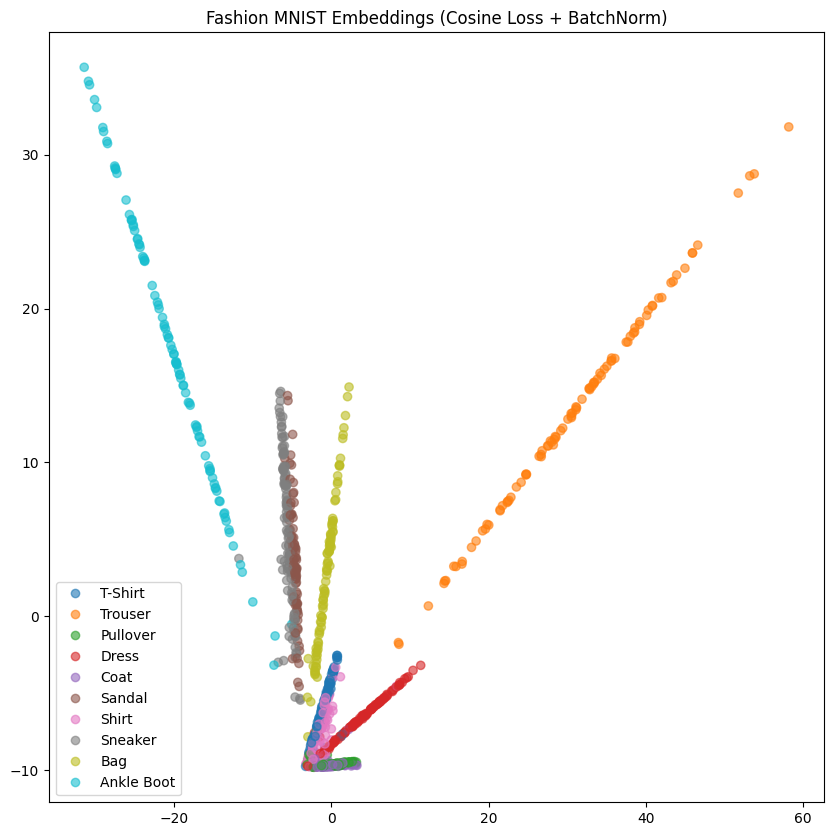

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np

# ... (Previous imports and setup remain the same) ...

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StableSiamese().to(device)



visualize_result(model, train_data) # Optional: Run if defined

criterion = nn.CosineEmbeddingLoss(margin=0.5)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_dataloader = DataLoader(siamese_dataset, shuffle=True, batch_size=128)

print("Starting Stabilized Training...")

loss_history = []
loss_history_same = []
loss_history_diff = []

for epoch in range(10):
    model.train()
    
    # Trackers for the whole epoch
    epoch_loss_total = 0.0
    epoch_loss_same = 0.0
    epoch_loss_diff = 0.0
    
    count_same = 0
    count_diff = 0
    
    for i, data in enumerate(train_dataloader, 0):
        img1, img2, label = data
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        
        # --- Label Conversion ---
        # 1.0 for Same, -1.0 for Different
        target = torch.where(label.squeeze() == 0, torch.tensor(1.0).to(device), torch.tensor(-1.0).to(device))
        
        optimizer.zero_grad()
        out1, out2 = model(img1, img2)
        
        # 1. Calculate the main loss for backprop
        loss = criterion(out1, out2, target)
        loss.backward()
        optimizer.step()
        
        # 2. METRICS CALCULATION (Does not affect training)
        # We calculate the loss again with reduction='none' to get values per-sample
        with torch.no_grad():
            raw_losses = F.cosine_embedding_loss(out1, out2, target, margin=0.5, reduction='none')
            
            # Create masks for Same (1) and Diff (-1)
            same_mask = (target == 1)
            diff_mask = (target == -1)
            
            # Sum up losses for this batch
            batch_loss_same = raw_losses[same_mask].sum().item()
            batch_loss_diff = raw_losses[diff_mask].sum().item()
            
            epoch_loss_same += batch_loss_same
            epoch_loss_diff += batch_loss_diff
            
            # Count how many same/diff samples were in this batch
            count_same += same_mask.sum().item()
            count_diff += diff_mask.sum().item()
            
        epoch_loss_total += loss.item()

    # Calculate averages
    avg_loss = epoch_loss_total / len(train_dataloader)
    
    # Avoid division by zero if a batch somehow missed a class (unlikely)
    avg_loss_same = epoch_loss_same / count_same if count_same > 0 else 0
    avg_loss_diff = epoch_loss_diff / count_diff if count_diff > 0 else 0

    loss_history.append(avg_loss)
    loss_history_same.append(avg_loss_same)
    loss_history_diff.append(avg_loss_diff)
    
    print(f"Epoch {epoch+1} | Total: {avg_loss:.4f} | Same Loss: {avg_loss_same:.4f} | Diff Loss: {avg_loss_diff:.4f}")

print("Training Done.")

visualize_result(model, train_data)

In [32]:
import torch
import torch.nn.functional as F

# Ensure model is in evaluation mode
model.eval()
print(f"{'ID':<5} | {'Label':<10} | {'Distance':<10} | {'Prediction':<10}")
print("-" * 45)

count = 0
same_dists = []
diff_dists = []

# Use no_grad to save memory and computation
with torch.no_grad():
    for i, data in enumerate(train_dataloader, 0):
        img1, img2, label = data
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)

        out1, out2 = model(img1, img2)
        
        # Calculate Distance (0 = Identical, 2 = Opposite)
        cosine_sim = F.cosine_similarity(out1, out2)
        distances = 1 - cosine_sim
        
        # Loop through the batch
        for j in range(len(label)):
            if count >= 100:
                break
            
            lbl = label[j].item()
            dist = distances[j].item()
            
            # Map label to text
            label_text = "Same" if lbl == 0 else "Diff"
            
            # Simple threshold check (assuming threshold 0.5 for prediction)
            pred = "Same" if dist < 0.5 else "Diff"
            match = "✓" if (lbl == 0 and dist < 0.5) or (lbl == 1 and dist > 0.5) else "✗"
            
            # Store for averages
            if lbl == 0:
                same_dists.append(dist)
            else:
                diff_dists.append(dist)

            print(f"{count+1:<5} | {label_text:<10} | {dist:.4f}     | {match}")
            count += 1
        
        if count >= 100:
            break

print("-" * 45)
print("SUMMARY:")
if same_dists:
    print(f"Avg Distance (Same): {sum(same_dists)/len(same_dists):.4f} (Should be low)")
if diff_dists:
    print(f"Avg Distance (Diff): {sum(diff_dists)/len(diff_dists):.4f} (Should be high)")

ID    | Label      | Distance   | Prediction
---------------------------------------------
1     | Same       | 0.0001     | ✓
2     | Diff       | 0.5061     | ✓
3     | Same       | 0.0009     | ✓
4     | Diff       | 0.4990     | ✗
5     | Same       | 0.0000     | ✓
6     | Diff       | 0.9225     | ✓
7     | Diff       | 0.6450     | ✓
8     | Diff       | 0.5581     | ✓
9     | Diff       | 0.0002     | ✗
10    | Diff       | 0.4255     | ✗
11    | Same       | 0.0000     | ✓
12    | Diff       | 0.5937     | ✓
13    | Diff       | 0.6547     | ✓
14    | Diff       | 0.6931     | ✓
15    | Same       | 0.0000     | ✓
16    | Same       | 0.0006     | ✓
17    | Diff       | 0.0052     | ✗
18    | Diff       | 0.9218     | ✓
19    | Diff       | 0.4949     | ✗
20    | Diff       | 0.5132     | ✓
21    | Diff       | 0.6711     | ✓
22    | Diff       | 0.5928     | ✓
23    | Diff       | 0.6795     | ✓
24    | Diff       | 0.8102     | ✓
25    | Same       | 0.0003     | ✓
26    | D